In [360]:
from sympy import symbols,lambdify
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import solve

In [361]:
x = symbols('x')

In [362]:
x_nodes = [0.847, 1.546, 1.834, 2.647, 2.910]
y_nodes = [-1.104, 1.042, 0.029, -0.344, -0.449]

In [363]:
def p(x_nodes, index):
    res = 1
    for i in range(len(x_nodes)):
        if i != index:
            res *= (x - x_nodes[i]) / (x_nodes[index] - x_nodes[i])
    return res

In [364]:
def lagrange(x_nodes, y_nodes):
    basises = [p(x_nodes, index) for index in range(len(x_nodes))]
    res = 0
    for index in range(len(x_nodes)):
        res += basises[index] * y_nodes[index]
    return res

In [365]:
example = lagrange(x_nodes, y_nodes)

In [366]:
print(example.subs({x : x_nodes[1] + x_nodes[2]}))

-5.11223674198989


In [367]:
f_lagrange = lambdify(x, example, 'numpy')

In [368]:
x_range = np.linspace(min(x_nodes) - 0.5, max(x_nodes) + 0.5, 400)
y_range = f_lagrange(x_range)

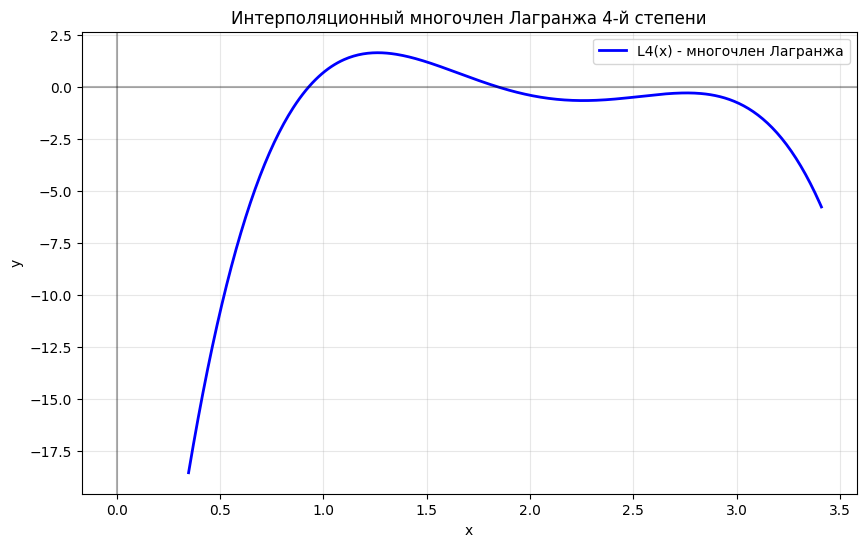

In [369]:
plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, 'b-', label='L4(x) - многочлен Лагранжа', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Интерполяционный многочлен Лагранжа 4-й степени')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

In [370]:
def final_difference(y_nodes, k , n):
    if n == 0:
        return y_nodes[k]
    else:
        return final_difference(y_nodes, k+1, n-1) - final_difference(y_nodes, k, n-1)

In [371]:
def divided_difference(x_nodes, y_nodes, n):
    if n == 0:
        return y_nodes[0]
    else:
        return (divided_difference(x_nodes[1:], y_nodes[1:], n-1) - divided_difference(x_nodes[:-1],y_nodes[:-1], n-1)) / (x_nodes[n] - x_nodes[0])

In [372]:
def build_final_diff_table(x_nodes, y_nodes):
    n = len(x_nodes)
    table_data = {'x_k': x_nodes, 'y_k': y_nodes}
    for order in range(1, n):
        col_name = f'Δ^{order}y_k' if order > 1 else 'Δy_k'
        values = []
        for k in range(n - order):
            val = final_difference(y_nodes, k, order)
            values.append(round(val, 4))
        values.extend([''] * (n - len(values)))
        table_data[col_name] = values

    df = pd.DataFrame(table_data)
    return df

def build_divided_diff_table(x_nodes, y_nodes):
    n = len(x_nodes)
    table_data = {'x_k': x_nodes, 'y_k': y_nodes}

    for order in range(1, n):
        col_name = f'{order}-го порядка'
        values = []
        for start in range(n - order):
            val = divided_difference(x_nodes[start:], y_nodes[start:], order)
            values.append(round(val, 4))
        values.extend([''] * (n - len(values)))
        table_data[col_name] = values

    df = pd.DataFrame(table_data)
    return df

In [373]:
print("Таблица конечных разностей:")
final_table = build_final_diff_table(x_nodes, y_nodes)
print(final_table.to_string(index=False))

print("Таблица разделенных разностей:")
divided_table = build_divided_diff_table(x_nodes, y_nodes)
print(divided_table.to_string(index=False))

Таблица конечных разностей:
  x_k    y_k   Δy_k Δ^2y_k Δ^3y_k Δ^4y_k
0.847 -1.104  2.146 -3.159  3.799 -4.171
1.546  1.042 -1.013   0.64 -0.372       
1.834  0.029 -0.373  0.268              
2.647 -0.344 -0.105                     
2.910 -0.449                            
Таблица разделенных разностей:
  x_k    y_k 1-го порядка 2-го порядка 3-го порядка 4-го порядка
0.847 -1.104       3.0701      -6.6742       5.2512       -3.513
1.546  1.042      -3.5174        2.778      -1.9961             
1.834  0.029      -0.4588       0.0553                          
2.647 -0.344      -0.3992                                       
2.910 -0.449                                                    


In [374]:
def newton(x_nodes, y_nodes):
    n = len(x_nodes)
    coefficients = []
    diff_table = y_nodes.copy()
    for i in range(n):
        coefficients.append(diff_table[0])
        
        new_diff = []
        for j in range(len(diff_table) - 1):
            val = (diff_table[j+1] - diff_table[j]) / (x_nodes[j+i+1] - x_nodes[j])
            new_diff.append(val)
        diff_table = new_diff
    N = coefficients[0]
    product = 1
    
    for i in range(1, n):
        product *= (x - x_nodes[i-1])
        N += coefficients[i] * product
    
    return N

In [375]:
example_2 = newton(x_nodes, y_nodes)

In [376]:
print(example_2.subs({x : x_nodes[1] + x_nodes[2]}))

-5.11223674198989


In [377]:
f = lambdify(x, example_2, 'numpy')

In [378]:
x_range = np.linspace(min(x_nodes) - 0.5, max(x_nodes) + 0.5, 400)
y_range = f(x_range)

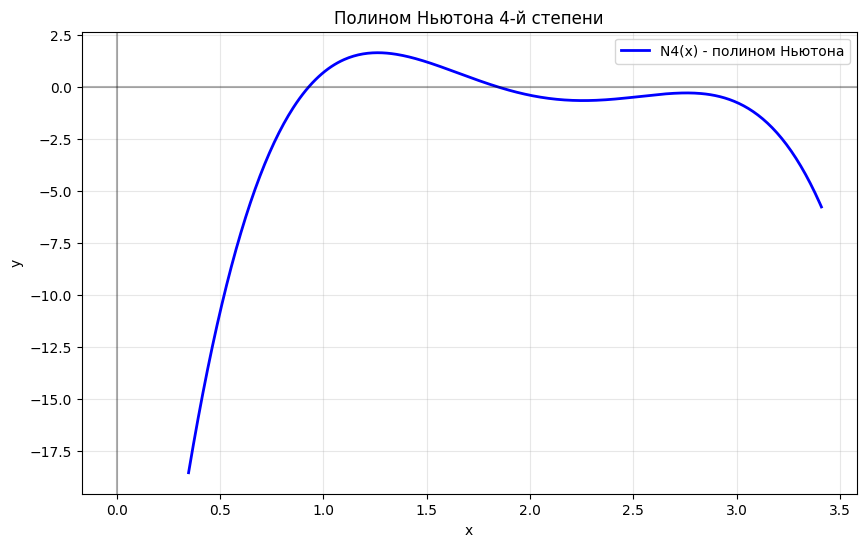

In [379]:
plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, 'b-', label='N4(x) - полином Ньютона', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Полином Ньютона 4-й степени')
plt.legend()
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

In [380]:
linear_splines = []

In [381]:
for i in range(len(x_nodes) - 1):

    A = np.array([
        [x_nodes[i],   1],
        [x_nodes[i+1], 1]
    ])
    B = np.array([y_nodes[i], y_nodes[i+1]])
    
    coeffs = solve(A, B)
    a_val, b_val = coeffs
    
    linear_splines.append((a_val, b_val, x_nodes[i], x_nodes[i+1]))

In [382]:
print("φ(x) = {")
for i, (a, b, x_start, x_end) in enumerate(linear_splines, 1):
    print(f"  {a:.4f}*x + {b:.4f},  {x_start} ≤ x ≤ {x_end}")
print("}")

φ(x) = {
  3.0701*x + -3.7044,  0.847 ≤ x ≤ 1.546
  -3.5174*x + 6.4798,  1.546 ≤ x ≤ 1.834
  -0.4588*x + 0.8704,  1.834 ≤ x ≤ 2.647
  -0.3992*x + 0.7128,  2.647 ≤ x ≤ 2.91
}


In [383]:
A1 = np.array([
    [x_nodes[0]**2, x_nodes[0], 1],
    [x_nodes[1]**2, x_nodes[1], 1],
    [x_nodes[2]**2, x_nodes[2], 1]
])
B1 = np.array([y_nodes[0], y_nodes[1], y_nodes[2]])

coeffs1 = solve(A1, B1)
a1, b1, c1 = coeffs1

A2 = np.array([
    [x_nodes[2]**2, x_nodes[2], 1],
    [x_nodes[3]**2, x_nodes[3], 1],
    [x_nodes[4]**2, x_nodes[4], 1]
])
B2 = np.array([y_nodes[2], y_nodes[3], y_nodes[4]])

coeffs2 = solve(A2, B2)
a2, b2, c2 = coeffs2

quad_splines = {
    'spline1': (a1, b1, c1, x_nodes[0], x_nodes[2]),
    'spline2': (a2, b2, c2, x_nodes[2], x_nodes[4])
}

In [384]:
print("φ(x) = {")
print(f"  {a1:.4f}*x² + {b1:.4f}*x + {c1:.4f},  x ∈ [{x_nodes[0]}; {x_nodes[2]}]")
print(f"  {a2:.4f}*x² + {b2:.4f}*x + {c2:.4f},  x ∈ [{x_nodes[2]}; {x_nodes[4]}]")
print("}")

φ(x) = {
  -6.6742*x² + 19.0415*x + -12.4440,  x ∈ [0.847; 1.834]
  0.0553*x² + -0.7068*x + 1.1391,  x ∈ [1.834; 2.91]
}


In [385]:
def linear_spline_func(x, splines):
    for a, b, x_start, x_end in splines:
        if x_start <= x <= x_end:
            return a * x + b
    return None

def quadratic_spline_func(x, quad_splines):
    for a, b, c, x_start, x_end in quad_splines.values():
        if x_start <= x <= x_end:
            return a * x**2 + b * x + c
    return None

In [386]:
x_plot = np.linspace(min(x_nodes), max(x_nodes), 1000)
y_linear = [linear_spline_func(x, linear_splines) for x in x_plot]
y_quadratic = [quadratic_spline_func(x, quad_splines) for x in x_plot]

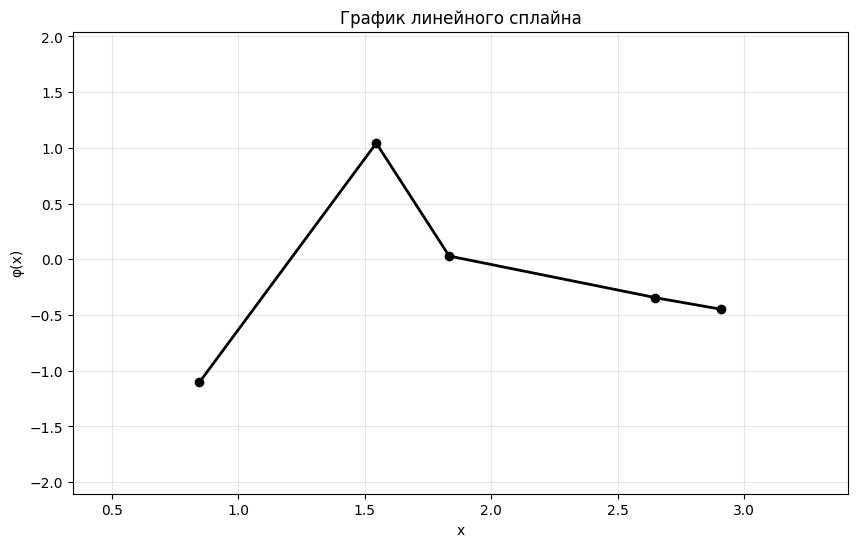

In [387]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_linear, 'k-', linewidth=2)
plt.plot(x_nodes, y_nodes, 'ko', markersize=6)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('φ(x)')
plt.title('График линейного сплайна')
plt.xlim(min(x_nodes) - 0.5, max(x_nodes) + 0.5)
plt.ylim(min(y_nodes) - 1, max(y_nodes) + 1)
plt.show()

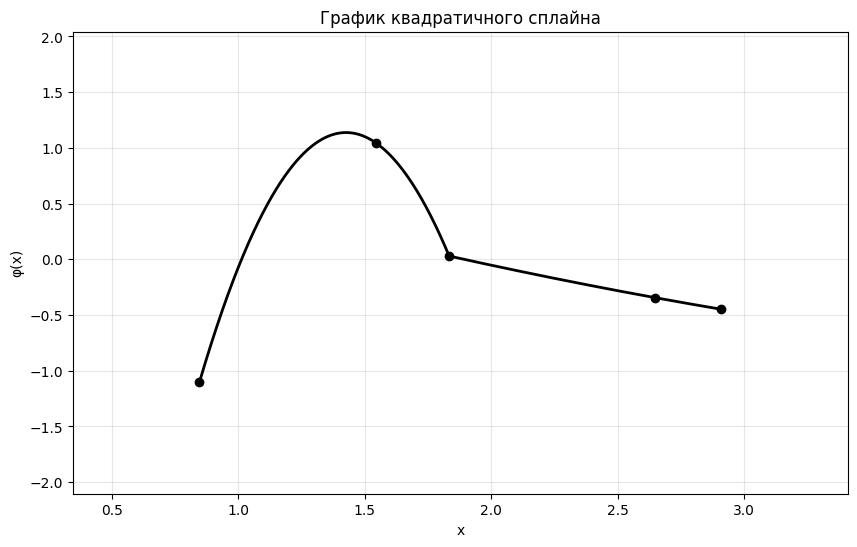

In [388]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_quadratic, 'k-', linewidth=2)
plt.plot(x_nodes, y_nodes, 'ko', markersize=6)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('φ(x)')
plt.title('График квадратичного сплайна')
plt.xlim(min(x_nodes) - 0.5, max(x_nodes) + 0.5)
plt.ylim(min(y_nodes) - 1, max(y_nodes) + 1)
plt.show()

In [389]:
x_plot = np.linspace(min(x_nodes) - 0.5, max(x_nodes) + 0.5, 1000)

In [390]:
y_polynom = f_lagrange(x_plot)
y_linear = [linear_spline_func(x, linear_splines) for x in x_plot]
y_quadratic = [quadratic_spline_func(x, quad_splines) for x in x_plot]

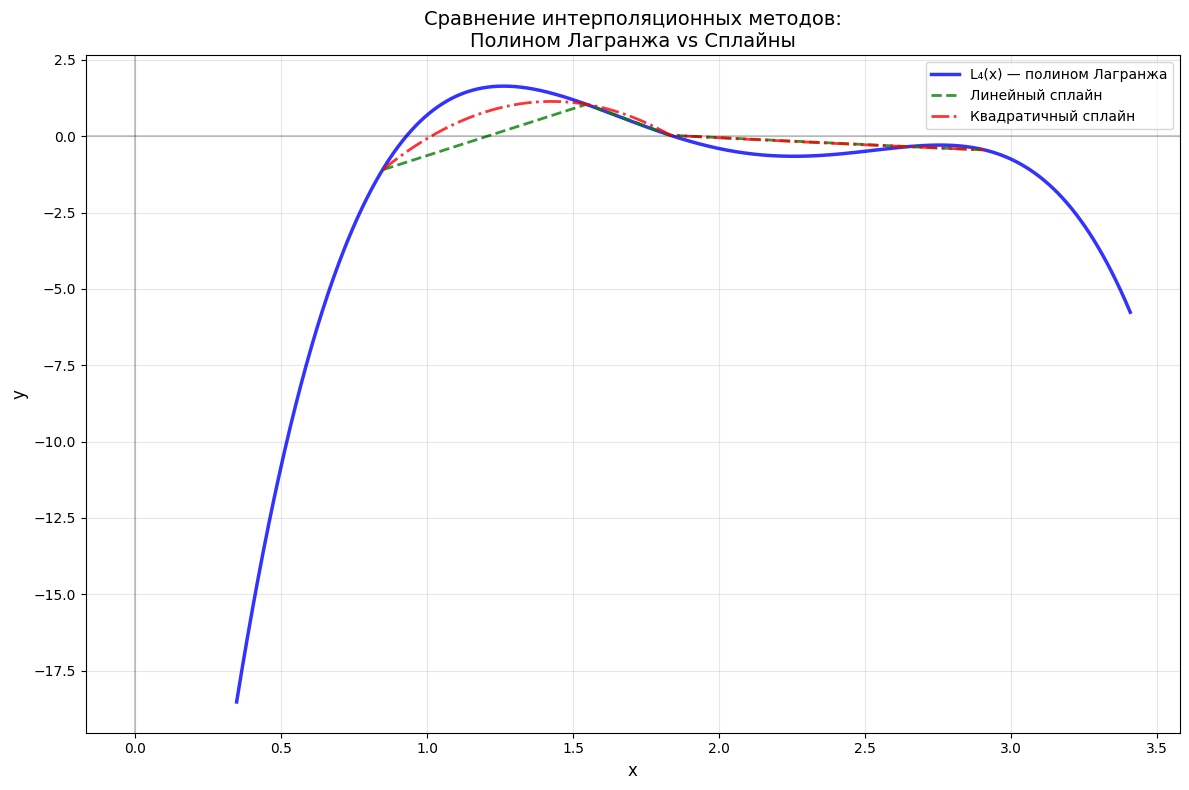

In [391]:
plt.figure(figsize=(12, 8))
plt.plot(x_plot, y_polynom, 'b-', linewidth=2.5, label='L₄(x) — полином Лагранжа', alpha=0.8)
plt.plot(x_plot, y_linear, 'g--', linewidth=2, label='Линейный сплайн', alpha=0.8)
plt.plot(x_plot, y_quadratic, 'r-.', linewidth=2, label='Квадратичный сплайн', alpha=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Сравнение интерполяционных методов:\nПолином Лагранжа vs Сплайны', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()